# Kepler Exoplanet Detection — KOI Features
> NASA's Kepler mission catalogued thousands of potential planets, but many turned out to be false signals from eclipsing binary stars or instrument noise. This notebook builds a machine learning pipeline to classify Kepler Objects of Interest (KOIs) using physical features — orbital period, planetary radius, equilibrium temperature, stellar properties, and confidence scores — distinguishing **confirmed exoplanets** from **false positives**, and ranking unresolved **candidates** by how likely they are to be real planets.

| Label | Class | Description |
| :---: | :---: | :--- |
| 0 | FALSE POSITIVE | Not a real exoplanet — likely an eclipsing binary or instrumental noise |
| 1 | CANDIDATE | Unresolved — astronomers haven't confirmed or ruled it out yet |
| 2 | CONFIRMED | Verified exoplanet |

**Dataset:** [Kepler Exoplanet Dataset on Kaggle](https://www.kaggle.com/datasets/gauravkumar2525/kepler-exoplanet-dataset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score
)
from sklearn.preprocessing import RobustScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import joblib

##confusion matrix helper

In [2]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.ylabel("actual")
    plt.xlabel("predicted")
    plt.show()

##load data

In [3]:
data = pd.read_csv("/kaggle/exoplanets_data.csv")
data = data.drop(columns=["kepoi_name"])

# multiplicity: how many KOIs share the same host star
# multi-planet systems are far more likely to be real (kepler multiplicity boost)
data["koi_multiplicity"] = data.groupby("kepid")["kepid"].transform("count")

data = data.drop(columns=["kepid"])  # drop kepid after computing multiplicity
data = data.dropna(subset=["koi_disposition"])
data["koi_disposition"] = data["koi_disposition"].astype(int)
# 0 = FALSE POSITIVE, 1 = CANDIDATE, 2 = CONFIRMED

print(f"data shape: {data.shape}")
print(data["koi_disposition"].value_counts())

data shape: (9564, 11)
koi_disposition
0    4839
2    2743
1    1982
Name: count, dtype: int64


##split

In [4]:
y = data["koi_disposition"]
X = data.drop(columns=["koi_disposition"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (7651, 10), test: (1913, 10)


## feature engineering

In [5]:
X_train = X_train.copy()
X_test = X_test.copy()

# score weighted by period
X_train["score_period"] = X_train["koi_score"] * X_train["koi_period"]
X_test["score_period"] = X_test["koi_score"] * X_test["koi_period"]

# planet to stellar radius ratio
X_train["radius_ratio"] = X_train["koi_prad"] / (X_train["koi_srad"] + 1e-5)
X_test["radius_ratio"] = X_test["koi_prad"] / (X_test["koi_srad"] + 1e-5)

# score squared
X_train["score_sq"] = X_train["koi_score"] ** 2
X_test["score_sq"] = X_test["koi_score"] ** 2

# equilibrium to stellar temperature ratio
X_train["temp_ratio"] = X_train["koi_teq"] / (X_train["koi_steff"] + 1e-5)
X_test["temp_ratio"] = X_test["koi_teq"] / (X_test["koi_steff"] + 1e-5)

## data preprocessing



In [6]:
# log transform skewed columns
log_cols = ["koi_period", "koi_insol", "koi_prad", "koi_srad"]
for col in log_cols:
    X_train[col] = np.log1p(X_train[col].clip(lower=0))
    X_test[col] = np.log1p(X_test[col].clip(lower=0))

# pipeline
pipe = Pipeline([
    ("imputer", IterativeImputer(max_iter=10, random_state=42)),
    ("scaler",  RobustScaler()),
])

X_train_processed = pipe.fit_transform(X_train)
X_test_processed = pipe.transform(X_test)

# smote
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_processed, y_train)

print(f"resampled shape: {X_train_res.shape}")

resampled shape: (11613, 14)


## baseline model: decision tree

decision tree classification report
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       968
           1       0.45      0.52      0.48       396
           2       0.81      0.74      0.78       549

    accuracy                           0.76      1913
   macro avg       0.71      0.71      0.71      1913
weighted avg       0.77      0.76      0.76      1913



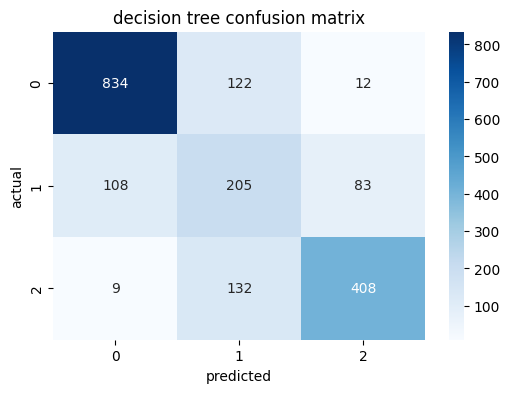

In [7]:
dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt.fit(X_train_res, y_train_res)

y_pred_dt = dt.predict(X_test_processed)
print("decision tree classification report")
print(classification_report(y_test, y_pred_dt, zero_division=0))
plot_cm(y_test, y_pred_dt, "decision tree confusion matrix")

## primary model: XGBoost

tuning xgboost...
best params: {'subsample': 0.85, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
xgboost classification report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       968
           1       0.54      0.56      0.55       396
           2       0.84      0.81      0.83       549

    accuracy                           0.80      1913
   macro avg       0.76      0.76      0.76      1913
weighted avg       0.80      0.80      0.80      1913



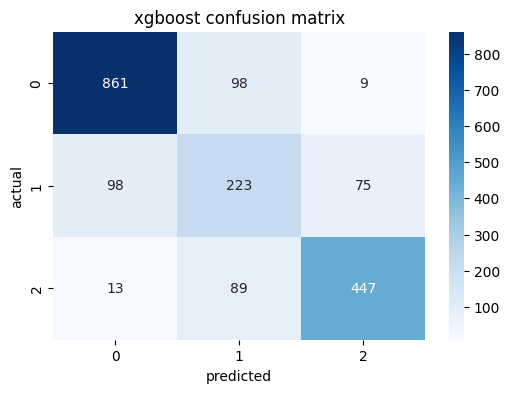

In [8]:
print("tuning xgboost...")

param_dist = {
    "n_estimators": [300, 500, 800],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_dist, n_iter=40, cv=cv,
    scoring="f1_macro",
    n_jobs=-1, random_state=42
)
search.fit(X_train_res, y_train_res)

best_xgb = search.best_estimator_
print("best params:", search.best_params_)

y_pred_xgb = best_xgb.predict(X_test_processed)
print("xgboost classification report")
print(classification_report(y_test, y_pred_xgb))
plot_cm(y_test, y_pred_xgb, "xgboost confusion matrix")

## ensemble model

stacking ensemble classification report
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       968
           1       0.55      0.56      0.56       396
           2       0.85      0.80      0.83       549

    accuracy                           0.80      1913
   macro avg       0.76      0.76      0.76      1913
weighted avg       0.81      0.80      0.80      1913



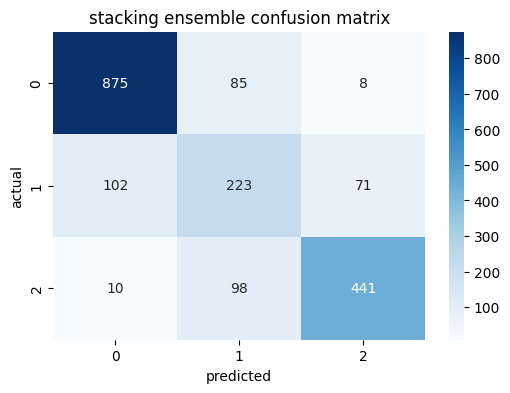

In [9]:
stack = StackingClassifier(
    estimators=[
        ("xgb", best_xgb),
        ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    passthrough=True
)

stack.fit(X_train_res, y_train_res)
y_pred_stack = stack.predict(X_test_processed)
print("stacking ensemble classification report")
print(classification_report(y_test, y_pred_stack))
plot_cm(y_test, y_pred_stack, "stacking ensemble confusion matrix")

## shap bar chart (multiclass)

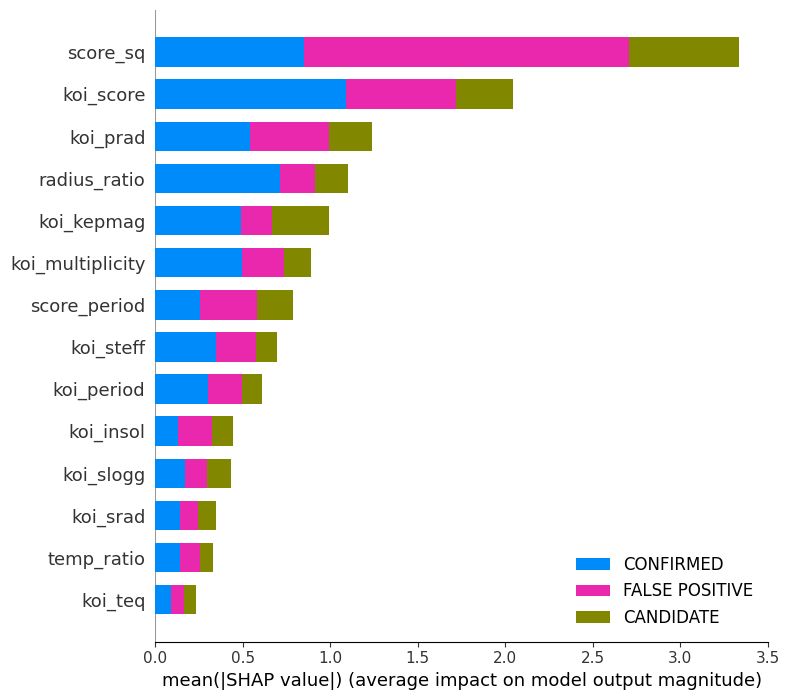

In [10]:
feature_names = X_train.columns.tolist()

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_processed)

plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values, X_test_processed,
    feature_names=feature_names,
    plot_type="bar",
    class_names=["FALSE POSITIVE", "CANDIDATE", "CONFIRMED"]
)
plt.show()

## feature ranking (multiclass)

In [11]:
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_class2 = shap_values[:, :, 2]
else:
    shap_class2 = shap_values[2]

mean_abs_shap = np.abs(shap_class2).mean(axis=0)
shap_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
shap_df = shap_df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("top features for CONFIRMED class:")
print(shap_df.head(10).to_string(index=False))

top features for CONFIRMED class:
         feature  mean_abs_shap
       koi_score       1.088168
        score_sq       0.851772
    radius_ratio       0.713434
        koi_prad       0.543680
koi_multiplicity       0.494361
      koi_kepmag       0.488027
       koi_steff       0.348097
      koi_period       0.298714
    score_period       0.255370
       koi_slogg       0.172859


##binary classification

binary classification report (FALSE POSITIVE vs CONFIRMED)
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       968
           1       0.97      0.96      0.96       549

    accuracy                           0.97      1517
   macro avg       0.97      0.97      0.97      1517
weighted avg       0.97      0.97      0.97      1517



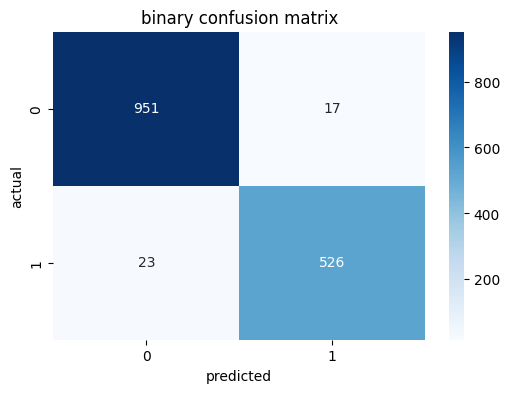

In [12]:
# binary classification
# candidate class excluded, too ambiguous to classify cleanly
mask_train = y_train_res != 1
mask_test = y_test != 1

X_binary_train = X_train_res[mask_train]
y_binary_train = (y_train_res[mask_train] == 2).astype(int)

X_binary_test = X_test_processed[mask_test]
y_binary_test = (y_test[mask_test] == 2).astype(int)

xgb_binary = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_binary.fit(X_binary_train, y_binary_train)

y_pred_binary = xgb_binary.predict(X_binary_test)
print("binary classification report (FALSE POSITIVE vs CONFIRMED)")
print(classification_report(y_binary_test, y_pred_binary))
plot_cm(y_binary_test, y_pred_binary, "binary confusion matrix")

## roc-auc and pr curves (binary)

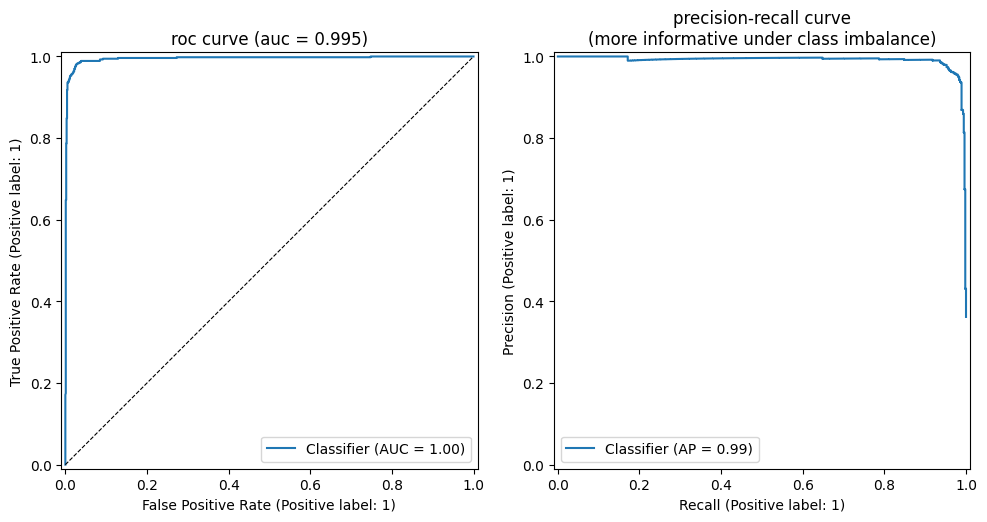


roc-auc: 0.9950


In [13]:
y_prob_binary = xgb_binary.predict_proba(X_binary_test)[:, 1]
auc_score = roc_auc_score(y_binary_test, y_prob_binary)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

RocCurveDisplay.from_predictions(y_binary_test, y_prob_binary, ax=ax1)
ax1.set_title(f"roc curve (auc = {auc_score:.3f})")
ax1.plot([0, 1], [0, 1], "k--", linewidth=0.8)

PrecisionRecallDisplay.from_predictions(y_binary_test, y_prob_binary, ax=ax2)
ax2.set_title("precision-recall curve\n(more informative under class imbalance)")

plt.tight_layout()
plt.show()

print()
print(f"roc-auc: {auc_score:.4f}")

## shap (binary)



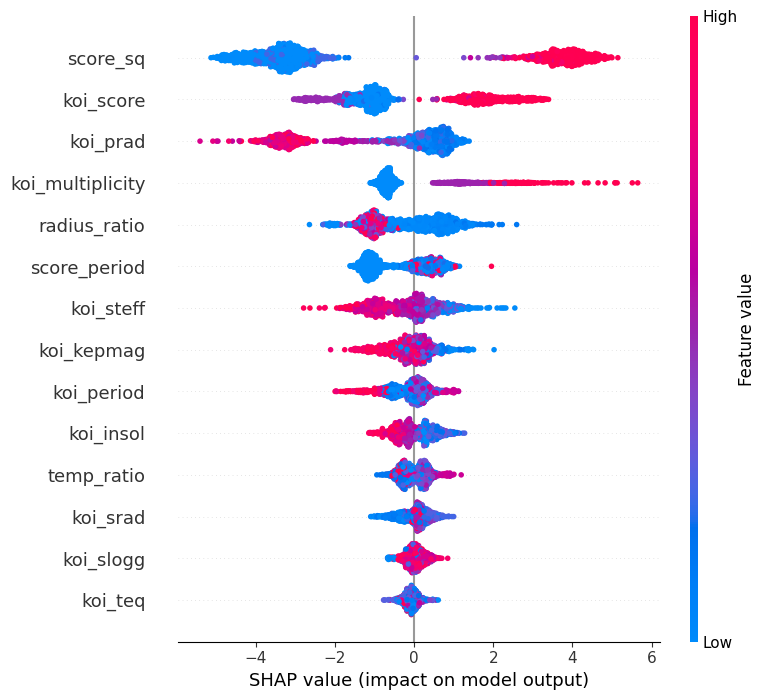


top features for binary (FALSE POSITIVE vs CONFIRMED):
         feature  mean_abs_shap
        score_sq       3.545839
       koi_score       1.528223
        koi_prad       1.405691
koi_multiplicity       0.964767
    radius_ratio       0.802913
    score_period       0.741179
       koi_steff       0.627278
      koi_kepmag       0.398913
      koi_period       0.383892
       koi_insol       0.371138


In [14]:
explainer_binary = shap.TreeExplainer(xgb_binary)
shap_values_binary = explainer_binary.shap_values(X_binary_test)

plt.figure(figsize=(6, 4))
shap.summary_plot(shap_values_binary, X_binary_test, feature_names=feature_names)
plt.show()

mean_abs_shap_binary = np.abs(shap_values_binary).mean(axis=0)
shap_df_binary = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap_binary})
shap_df_binary = shap_df_binary.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print()
print("top features for binary (FALSE POSITIVE vs CONFIRMED):")
print(shap_df_binary.head(10).to_string(index=False))

## candidate priority ranking (NOT classification)

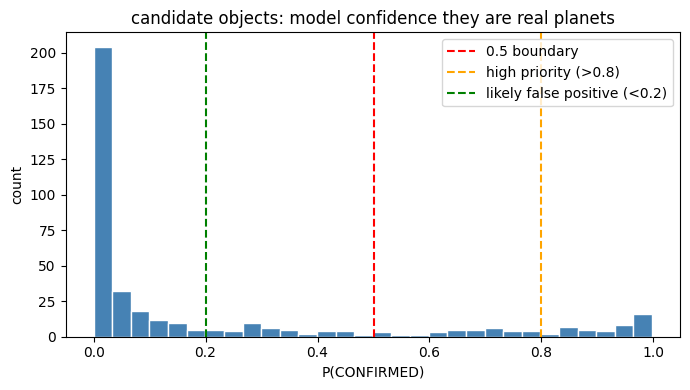


candidates model is >80% confident are real planets : 42
candidates model is >80% confident are false positives: 281
genuinely ambiguous (40-60%) : 13

top 10 highest-priority candidates:
 candidate_index  p_confirmed      priority
            2187     0.997576 high priority
             864     0.996574 high priority
            1682     0.995474 high priority
            1404     0.993327 high priority
            2760     0.992938 high priority
            7315     0.990015 high priority
            1535     0.983483 high priority
            2984     0.982132 high priority
            4708     0.980008 high priority
            3735     0.977875 high priority


In [15]:
candidate_mask = y_test == 1
X_candidates = X_test_processed[candidate_mask]

probs = best_xgb.predict_proba(X_candidates)
confirmed_prob = probs[:, 2]

plt.figure(figsize=(7, 4))
plt.hist(confirmed_prob, bins=30, color="steelblue", edgecolor="white")
plt.axvline(0.5, color="red", linestyle="--", label="0.5 boundary")
plt.axvline(0.8, color="orange", linestyle="--", label="high priority (>0.8)")
plt.axvline(0.2, color="green", linestyle="--", label="likely false positive (<0.2)")
plt.xlabel("P(CONFIRMED)")
plt.ylabel("count")
plt.title("candidate objects: model confidence they are real planets")
plt.legend()
plt.tight_layout()
plt.show()

# priority ranking — descriptive, not prescriptive
candidate_indices = y_test[candidate_mask].index
priority_df = pd.DataFrame({
    "candidate_index": candidate_indices,
    "p_confirmed": confirmed_prob,
    "priority": pd.cut(
        confirmed_prob,
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=["very unlikely", "unlikely", "ambiguous", "likely", "high priority"]
    )
}).sort_values("p_confirmed", ascending=False)

print()
print(f"candidates model is >80% confident are real planets : {(confirmed_prob > 0.8).sum()}")
print(f"candidates model is >80% confident are false positives: {(confirmed_prob < 0.2).sum()}")
print(f"genuinely ambiguous (40-60%) : {((confirmed_prob > 0.4) & (confirmed_prob < 0.6)).sum()}")
print()
print("top 10 highest-priority candidates:")
print(priority_df.head(10).to_string(index=False))

## save models

In [16]:
joblib.dump(best_xgb, "xgb_multiclass.pkl")
joblib.dump(xgb_binary, "xgb_binary.pkl")
joblib.dump(stack, "stacking_ensemble.pkl")
joblib.dump(pipe, "preprocessing_pipeline.pkl")

print("saved:")
print("xgb_multiclass.pkl — multiclass model (FALSE POSITIVE / CANDIDATE / CONFIRMED)")
print("xgb_binary.pkl — binary model (FALSE POSITIVE vs CONFIRMED)")
print("stacking_ensemble.pkl — stacking ensemble")
print("preprocessing_pipeline.pkl — imputer + scaler in correct order")

saved:
xgb_multiclass.pkl — multiclass model (FALSE POSITIVE / CANDIDATE / CONFIRMED)
xgb_binary.pkl — binary model (FALSE POSITIVE vs CONFIRMED)
stacking_ensemble.pkl — stacking ensemble
preprocessing_pipeline.pkl — imputer + scaler in correct order
